# **ADVANCED EXPERIMENTS & BONUS MODELS: CLASSIFICATION**

---

## **1. Import Libraries**

In [1]:
# Import library for advanced experiments
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
import time
import tracemalloc as _tmal

# Import the custom models implemented from scratch in models.py
from models import BinaryLogisticRegression, KernelLogisticRegression, GaussianNaiveBayes, LinearDiscriminantAnalysis
from models import ProbitRegression, evaluate_noise_robustness, BayesianLogisticRegression

from visualizations import (
    compare_model_probability_distributions, plot_logit_vs_probit_pca_boundary,
    plot_noise_robustness, plot_covariance_heatmap,
    plot_bayesian_decision_boundary_with_uncertainty,
    plot_decision_boundary_comparison,
    plot_structural_risk_minimization_srm
)


# Ensure plots are displayed inline
%matplotlib inline

## **2. Load Data for Model**

In [2]:
# Define file paths
train_path = '../../data/processed/Room_Occupancy_train.csv'
val_path = '../../data/processed/Room_Occupancy_val.csv'
test_path = '../../data/processed/Room_Occupancy_test.csv'

# Load the datasets
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Define the target variable
target_col = 'Room_Occupancy_Count'

# Define time and memory usage
_perf_records = {}  # {name: {'time_s': float, 'mem_mb': float}}

# Split features and target labels
X_train = train_df.drop(columns=[target_col]).values
y_train = train_df[target_col].values

X_val= val_df.drop(columns=[target_col]).values
y_val = val_df[target_col].values

X_test = test_df.drop(columns=[target_col]).values
y_test = test_df[target_col].values

# Display the shape of the datasets
print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Testing set shape:    {X_test.shape}")

Training set shape:   (6077, 31)
Validation set shape: (2026, 31)
Testing set shape:    (2026, 31)


## **3. Probit Regression Model**

Cả Probit và Logistic Regression đều là những phương pháp nền tảng trong họ *Generalized Linear Models - GLMs* dành cho bài toán phân lớp nhị phân. Mục tiêu chung của chúng là làm cầu nối ánh xạ một điểm số tuyến tính (raw score) $a = \mathbf{w}^\top \mathbf{x}$ vào không gian xác suất $[0, 1]$. 

Điểm khác biệt toán học duy nhất và cốt lõi nhất giữa hai mô hình này nằm ở việc lựa chọn *hàm liên kết* và giả định về cấu trúc nhiễu của hệ thống.

**Logistic Regression: Logit Link & Sigmoid**

Trong mô hình Logistic, xác suất được mô hình hóa dựa trên tỷ lệ chênh lệch (odds). Hàm liên kết được sử dụng là hàm Logit $\eta = \ln\left(\frac{p}{1-p}\right)$. Bằng cách nghịch đảo hàm Logit, ta thu được hàm kích hoạt Sigmoid:
$$p(Y=1 | \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x}) = \frac{1}{1 + \exp(-\mathbf{w}^\top \mathbf{x})}$$

**Probit Regression: Latent Variable Perspective**

Mô hình Probit tiếp cận bài toán theo cấu trúc vi mô của *mô hình biến ẩn*. Thay vì ánh xạ trực tiếp, Probit giả định tồn tại một biến liên tục không quan sát được $Y^*$, đại diện cho khuynh hướng đằng sau quyết định:
$$Y^* = \mathbf{w}^\top \mathbf{x} + \epsilon$$

Quyết định nhị phân cuối cùng ($Y \in \{0, 1\}$) được kích hoạt khi biến ẩn này vượt qua ngưỡng $0$ ($Y^* > 0$). Trong Probit, sai số $\epsilon$ được giả định tuân thủ nghiêm ngặt *phân phối chuẩn tắc $\mathcal{N}(0, 1)$*. Do đó, xác suất để sự kiện xảy ra chính là hàm phân phối tích lũy (CDF) của phân phối chuẩn, ký hiệu là $\Phi$:
$$p(Y=1 | \mathbf{x}) = \Phi(\mathbf{w}^\top \mathbf{x})$$

### **3.1. Data Preparation: Transformation to Binary Classification**

Bản chất của hàm Probit truyền thống được thiết kế tối ưu cho bài toán phân lớp nhị phân. Do tập dữ liệu gốc của chúng ta là phân lớp đa lớp ($K=4$), để đối sánh trực tiếp sức mạnh của mô hình Probit và Logistic Regression, nhóm sẽ tiến hành binarize nhãn dữ liệu.

**Quy tắc chuyển đổi:**
* *Class 0 (Phòng trống - Empty Room):* Giữ nguyên nhãn `0`.
* *Class 1, 2, 3 (Phòng có người - Occupied):* Gộp chung thành nhãn `1`.

In [3]:
# 1. Convert labels to binary classification: 0 -> Empty room, 1 -> Occupied
y_train_bin = np.where(y_train > 0, 1, 0)
y_val_bin = np.where(y_val > 0, 1, 0)
y_test_bin = np.where(y_test > 0, 1, 0)

print(f"Binary label distribution (Train): {np.bincount(y_train_bin)}")
print(f"Binary label distribution (Test): {np.bincount(y_test_bin)}\n")

Binary label distribution (Train): [4937 1140]
Binary label distribution (Test): [1646  380]



In [4]:
print("\tTRAINING LOGIT AND PROBIT MODELS")
_tmal.start(); _t0 = time.time()
logit_model = BinaryLogisticRegression(method='newton', max_iter=100)
logit_model.fit(X_train, y_train_bin)
_perf_records['Logit (Binary LR, Newton)'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
_tmal.start(); _t0 = time.time()
probit_model = ProbitRegression(learning_rate=0.5, max_iter=2000, verbose=True)
probit_model.fit(X_train, y_train_bin)
_perf_records['Probit Regression (GD)'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
print("Training complete!")

	TRAINING LOGIT AND PROBIT MODELS
[Probit] Converged at iteration 1157
Training complete!


### **3.2. Comparative Analysis: Output Probabilities**

**Mục tiêu:** Khảo sát sự khác biệt về phân phối xác suất dự đoán của hai mô hình trên tập Test. 

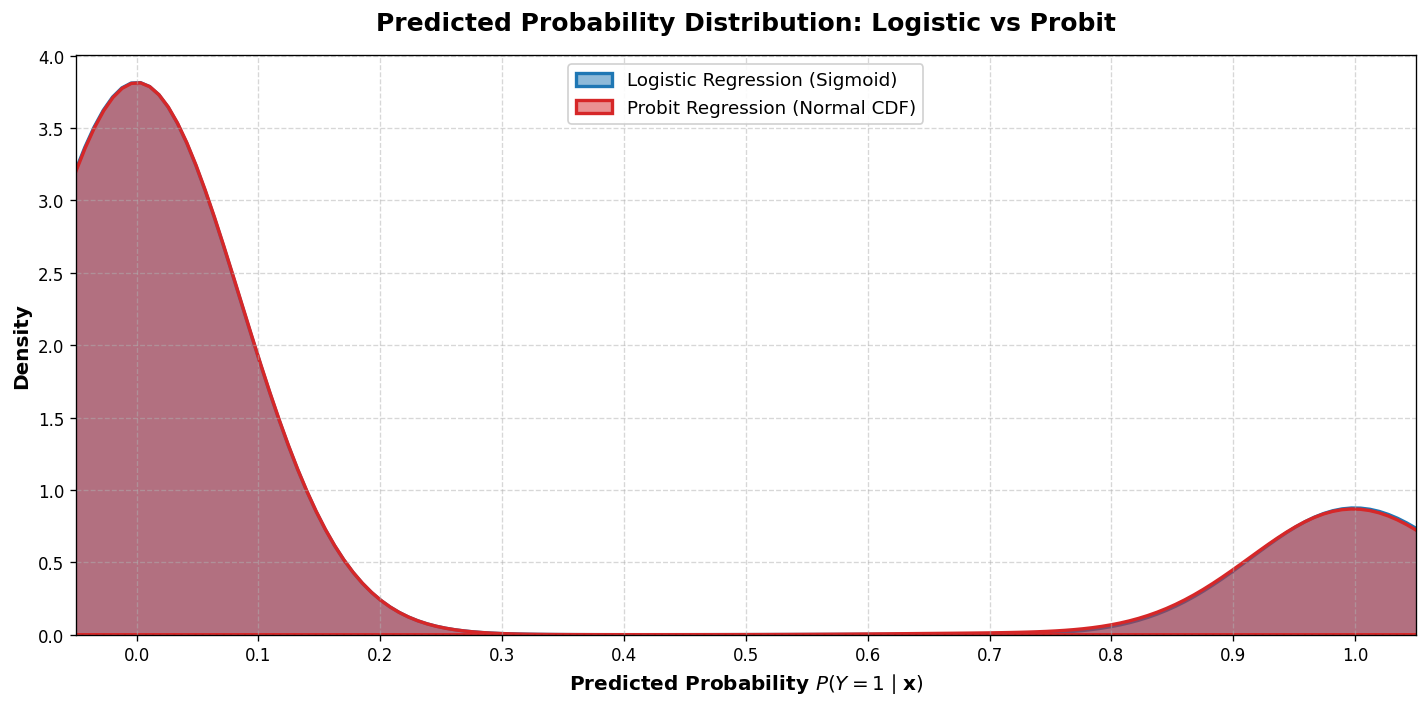

In [5]:
compare_model_probability_distributions(
    logit_model,
    probit_model,
    X_test
)

Dựa vào biểu đồ mật độ phân phối (KDE Plot) phía trên, chúng ta rút ra những nhận định quan trọng về đặc tính của bộ dữ liệu Room Occupancy:

1. Phân phối xác suất của Logistic Regression (màu xanh) và Probit Regression (màu đỏ) gần như *chồng khít lên nhau hoàn toàn*.
2. Đồ thị cho thấy mật độ xác suất ở khu vực giữa (từ $0.2$ đến $0.8$) gần như bằng $0$. Thay vào đó, mô hình dồn toàn bộ dự đoán thành hai đỉnh (peaks) cực đoan: một đỉnh khổng lồ tại $0.0$ (phòng trống) và một đỉnh nhỏ hơn tại $1.0$ (có người).
3. Hiện tượng này là minh chứng rõ ràng cho việc bộ dữ liệu của chúng ta *có khả năng phân chia tuyến tính ở mức độ cực kỳ cao*. Điểm số thô $z = \mathbf{w}^\top \mathbf{x}$ sinh ra có giá trị tuyệt đối rất lớn. Khi $z \to -\infty$ hoặc $z \to +\infty$, cả hàm Sigmoid và hàm Normal CDF đều bão hòa tại ngưỡng $0$ và $1$. 

**Kết luận:** Khi đối mặt với một bài toán mà dữ liệu phân tách quá rõ ràng, hiệu ứng khác biệt về cấu trúc "đuôi mỏng" hay "đuôi dày" của các hàm liên kết (link Functions) bị triệt tiêu hoàn toàn. Trong kịch bản này, việc lựa chọn giữa Logit hay Probit không mang lại sự khác biệt đáng kể về mặt dự đoán xác suất đầu ra.

### **3.3. Comparative Analysis: Decision Boundaries**

**Mục tiêu:** Trực quan hóa ranh giới phân tách của Logit và Probit bằng kỹ thuật *overlaying* trên cùng một hệ trục tọa độ PCA 2D. Phương pháp này giúp khắc phục nhược điểm mất tiêu cự khi quan sát side-by-side, làm lộ rõ những điểm khác biệt vi mô nhất ở cấu trúc không gian của hai thuật toán.

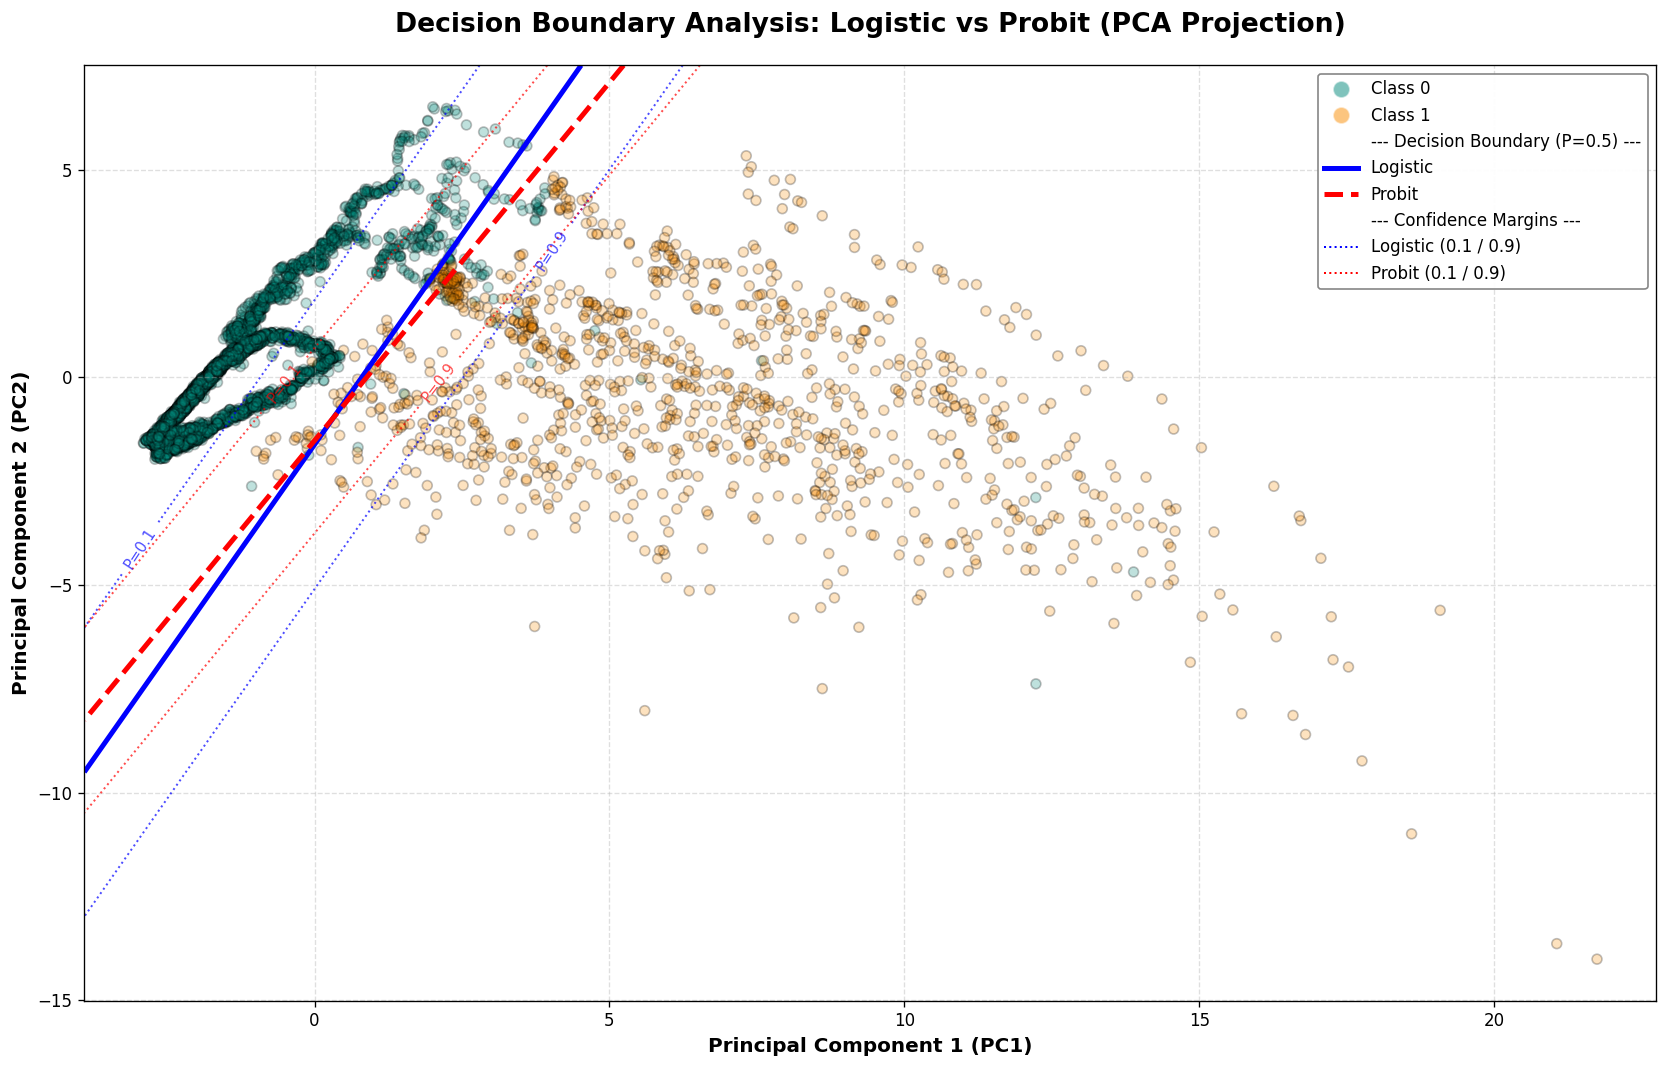

In [6]:
plot_logit_vs_probit_pca_boundary(
    X_train,
    y_train_bin,
    logit_model_cls=BinaryLogisticRegression,
    probit_model_cls=ProbitRegression
)

Từ đồ thị thu được, chúng ta quan sát thấy 2 hiện tượng toán học cực kỳ rõ rệt:

1. *$P = 0.5$:* Đường nét liền màu xanh (Logistic) và đường nét đứt màu đỏ (Probit) ở mức xác suất $0.5$ gần như *trùng khít lên nhau tạo thành một dải duy nhất*. Điều này khẳng định tại vị trí biến ẩn $Y^* \approx 0$, hai hàm liên kết (Logit link và Normal CDF) có đạo hàm và hành vi ánh xạ giống hệt nhau, phân chia trực giao không gian thành 2 nửa hoàn toàn tương đương.

2. *Margins $P = 0.1$ và $P = 0.9$):* Khi di chuyển ra xa đường biên cốt lõi, sự khác biệt bắt đầu lộ diện rành mạch. Hãy chú ý các đường chấm gạch mỏng (mức tự tin $10\%$ và $90\%$):
   * Các đường lề màu đỏ (Probit) luôn *nằm sát* đường ranh giới trung tâm hơn.
   * Các đường lề màu xanh (Logistic) lại *mở rộng* ra xa hơn.
   
   *=> Ý nghĩa:* Đồ thị đã chứng minh bằng mắt thường tính chất *thin tails* của phân phối chuẩn trong mô hình Probit. Probit đẩy xác suất đạt đến cực $0.1$ hoặc $0.9$ nhanh hơn rất nhiều chỉ với một sự thay đổi nhỏ về khoảng cách hình học. Ngược lại, Logistic Regression cung cấp một *buffer zone* rộng rãi và thoai thoải hơn, giúp mô hình bớt nhạy cảm và khoan dung hơn với các điểm dữ liệu nhiễu nằm len lỏi ở vùng biên.

### **3.3. Robustness Stress-Test: Sensitivity to Noisy Labels**

**Mục tiêu:** Trong môi trường thực tế, dữ liệu thu thập từ cảm biến (IoT sensors) không bao giờ hoàn hảo và thường xuyên chứa các nhãn bị sai lệch (Noisy Labels) do lỗi đường truyền hoặc nhiễu môi trường. Mục tiêu của phần này là kiểm tra *robustness* của hai thuật toán khi đối mặt với dữ liệu bẩn.

**Stress-Test Design:**
1. Nhóm sẽ chủ động thêm nhiễu vào tập huấn luyện bằng kỹ thuật *Random Label Flipping*. 
2. Một tỷ lệ phần trăm dữ liệu nhất định sẽ bị ép đổi nhãn ($0 \leftrightarrow 1$). Các tỷ lệ nhiễu được thử nghiệm tăng dần: $0\%, 5\%, 10\%, 15\%, 20\%, 30\%$.
3. Huấn luyện lại cả hai mô hình (Logistic và Probit) trên các tập dữ liệu nhiễu này.
4. Đánh giá độ chính xác của chúng trên tập test gốc (dữ liệu sạch hoàn toàn) để vẽ ra *degradation curve*.

Starting noise robustness evaluation...

[INFO] Noise level: 00%
[INFO] Noise level: 05%
[INFO] Noise level: 10%
[INFO] Noise level: 15%
[INFO] Noise level: 20%
[INFO] Noise level: 30%

Evaluation completed.


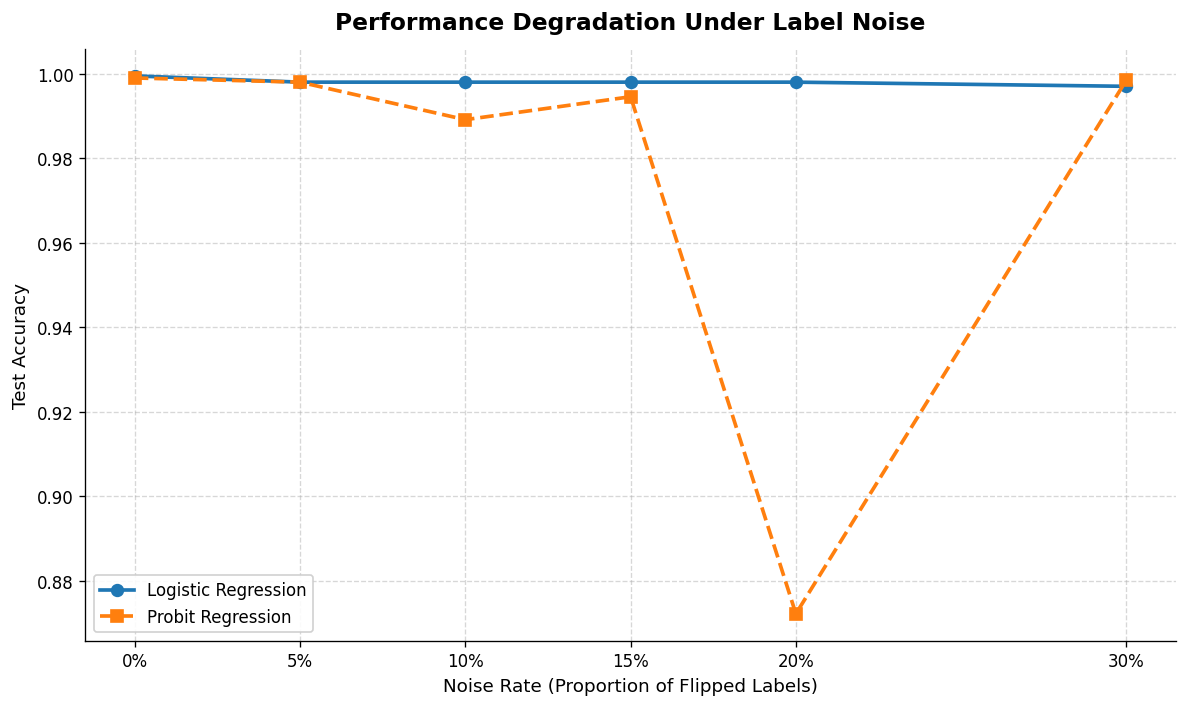

In [7]:
_tmal.start(); _t0 = time.time()
noise_rates = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]

acc_logit, acc_probit = evaluate_noise_robustness(
    X_train, y_train_bin,
    X_test, y_test_bin,
    noise_rates,
    logistic_model_cls=BinaryLogisticRegression,
    probit_model_cls=ProbitRegression,
    logistic_params={"method": "newton", "max_iter": 100},
    probit_params={"learning_rate": 0.5, "max_iter": 2000}
)

_perf_records['Noise Robustness Evaluation (Logit + Probit)'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
plot_noise_robustness(noise_rates, acc_logit, acc_probit)

### **3.4. Discussion & Conclusion: Why Logit is More Robust?**

Nhìn vào đường cong suy giảm hiệu năng degradation curve từ thực nghiệm stress-test, chúng ta có nhận xét sau:

**1. Nhận xét trực quan:**
* *Tại điều kiện lý tưởng (không có nhiễu):* Hiệu năng của cả Logistic và Probit là gần như tương đương và tiệm cận nhau hoàn toàn.
* *Khi tỷ lệ nhiễu tăng dần:* Đồ thị bắt đầu có sự phân kỳ rõ rệt. Đường cong của Logistic Regression (đường nét liền) cho thấy robustness đáng kinh ngạc, duy trì độ chính xác ở mức cao và cực kỳ ổn định. Ngược lại, mô hình Probit (đường nét đứt) phản ứng khá tiêu cực với dữ liệu bẩn, biên độ dao động lớn hơn và hiệu năng cắm dốc mạnh mẽ khi tỷ lệ lật nhãn bị đẩy lên mức cao.

**2. Tại sao Logistic lại bền vững hơn Probit?**

Câu trả lời cốt lõi nằm ở khái niệm *Tail Heaviness* trong lý thuyết xác suất:

* **Cơ chế của Probit (Thin Tails):** Hàm liên kết của Probit dựa trên phân phối chuẩn tắc, vốn có đặc trưng đuôi phân phối suy giảm nhanh. Xác suất ở vùng đuôi tiến về $0$ với tốc độ $\mathcal{O}(e^{-z^2/2})$. Trong quá trình tối ưu hóa Log-Likelihood, khi mô hình gặp các điểm dữ liệu bị nhiễu hoặc gán nhãn sai (mislabelled samples), xác suất dự đoán có thể tiến rất gần $0$, dẫn đến giá trị hàm mất mát $\log(0) \to -\infty$. Để tránh mức phạt này, thuật toán buộc phải điều chỉnh mạnh ranh giới quyết định trên toàn bộ không gian đặc trưng, làm suy giảm khả năng tổng quát hóa của mô hình.
* **Cơ chế của Logistic (Heavy Tails):** Hàm Sigmoid trong Logistic Regression có đặc tính đuôi phân phối dày hơn, với tốc độ suy giảm $\mathcal{O}(e^{-z})$. Do đó, mức phạt đối với các điểm bị phân loại sai tăng theo tốc độ gần tuyến tính theo khoảng cách trong không gian đặc trưng. Đặc tính này khiến Logistic Regression có tính bền vững với nhiễu (robustness to noise/outliers) cao hơn, vì mô hình chấp nhận một mức sai lệch cục bộ nhằm duy trì ranh giới quyết định tối ưu cho phần lớn dữ liệu.

**Kết luận:** Thông qua thực nghiệm so sánh, có thể rút ra rằng trong các bối cảnh dữ liệu thực tế—đặc biệt là dữ liệu cảm biến IoT vốn chứa nhiễu và sai lệch—Logistic Regression là lựa chọn ổn định và đáng tin cậy hơn. Probit Regression chỉ phù hợp khi tồn tại giả định mạnh rằng biến tiềm ẩn của hệ thống tuân theo phân phối chuẩn một cách chính xác.

## **4. Bayesian Logistic Regression via Laplace Approximation**

### **4.1. Theoretical Foundation: From Point Estimates to Uncertainty**

Trong các mô hình học máy truyền thống tối ưu hóa bằng Maximum Likelihood Estimation (MLE), chúng ta chỉ thu được một "điểm ước lượng" - tức một bộ trọng số $\mathbf{w}$ duy nhất. Cách tiếp cận này khiến mô hình luôn tỏ ra tự tin một cách thái quá (vì chỉ có một đáp án duy nhất), ngay cả khi gặp dữ liệu hoàn toàn lạ.

Để khắc phục, ta sử dụng *xấp xỉ Laplace* để chuyển đổi hệ thống sang khung thống kê Bayes. Mục tiêu là ước lượng toàn bộ phân phối hậu nghiệm của trọng số $p(\mathbf{w} | \mathcal{D})$. 

Dựa trên khai triển Taylor bậc 2 quanh điểm Cực đại hậu nghiệm (MAP - Maximum A Posteriori), phân phối này được xấp xỉ bằng một phân phối chuẩn đa biến: 
  $$q(\mathbf{w}) = \mathcal{N}(\mathbf{w} | \mathbf{w}_{MAP}, \mathbf{A}^{-1})$$

Ma trận chính xác $\mathbf{A}$ chính là ma trận Hessian âm ($\mathbf{A} = -\nabla \nabla \ln p(\mathbf{w} | \mathcal{D}) |_{\mathbf{w}_{MAP}}$). Bề mặt hàm Loss càng dốc (dữ liệu dày đặc), $\mathbf{A}$ càng lớn, dẫn đến ma trận hiệp phương sai $\mathbf{A}^{-1}$ càng nhỏ $\rightarrow$ Mô hình cực kỳ tự tin. Vùng thiếu dữ liệu, Loss nằm ngang, $\mathbf{A}^{-1}$ lớn $\rightarrow$ Mô hình bất định.

### **4.2. Computing the MAP Estimate and Posterior Covariance**

Quá trình xấp xỉ Laplace bắt đầu bằng việc tìm kiếm điểm cực đại hậu nghiệm (MAP - Maximum A Posteriori) và đánh giá độ cong của hàm mục tiêu tại điểm đó.

* **Bước 1 (Tìm $\mathbf{w}_{MAP}$):** Về mặt toán học, $\mathbf{w}_{MAP}$ chính là bộ trọng số thu được khi ta tối ưu hóa mô hình Logistic Regression có tích hợp thêm hình phạt L2-Regularization. Hình phạt L2 này tương đương với việc áp đặt một Gaussian Prior lên các trọng số. *(Lưu ý: Hệ số chặn $w_0$ sẽ không bị regularize để đảm bảo tính linh hoạt của ranh giới).*
* **Bước 2 (Tính Hessian $\mathbf{A}$):** Tại điểm hội tụ, ta tính toán ma trận Hessian $\mathbf{A}$ của hàm negative log-posterior. Ma trận này đại diện cho độ cong của bề mặt hàm mục tiêu:
  $$\mathbf{A} = \frac{1}{N} \mathbf{X}^\top \mathbf{R} \mathbf{X} + \lambda \mathbf{I}$$
  *(Trong đó $\mathbf{R}$ là ma trận đường chéo chứa các giá trị phương sai dự đoán $y_n(1-y_n)$, $\lambda$ là hệ số điều chuẩn và ma trận định danh $\mathbf{I}$ đã loại trừ phần tử của hệ số chặn).*
* **Bước 3 (Xây dựng Posterior):** Ma trận hiệp phương sai (Covariance Matrix) của các trọng số chính là nghịch đảo của Hessian: $\mathbf{\Sigma} = \mathbf{A}^{-1}$. Phân phối hậu nghiệm xấp xỉ lúc này có dạng: $q(\mathbf{w}) = \mathcal{N}(\mathbf{w} | \mathbf{w}_{MAP}, \mathbf{\Sigma})$.

	RUNNING LAPLACE APPROXIMATION
[BayesianLogistic] Converged at iteration 6


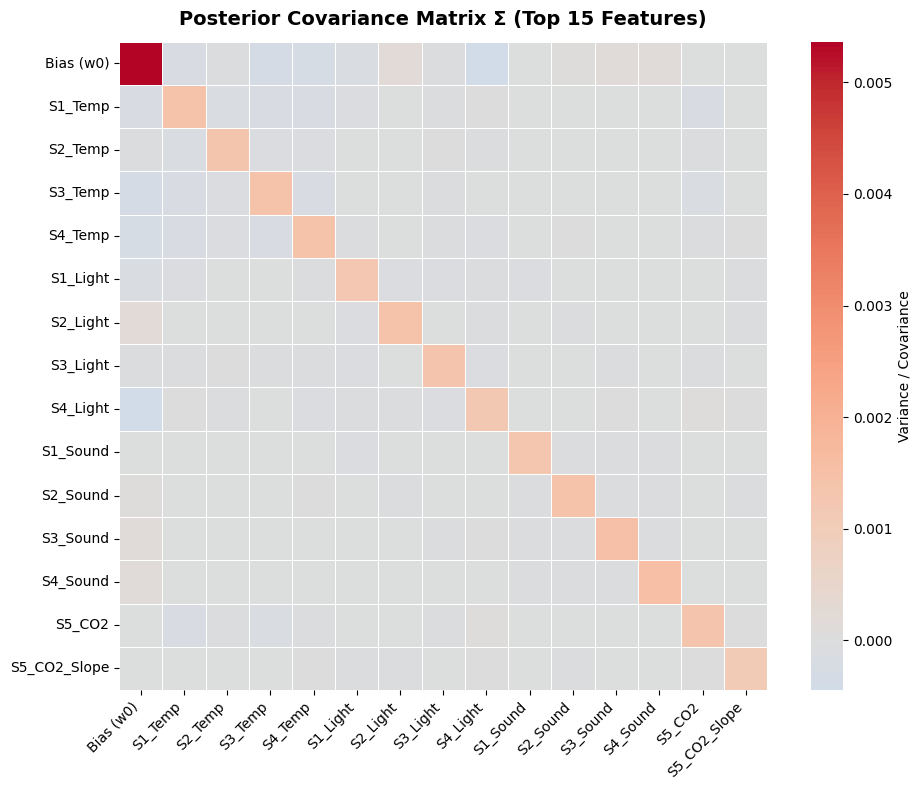

In [8]:
print("\tRUNNING LAPLACE APPROXIMATION")

# Train model
_tmal.start(); _t0 = time.time()
model_bayes = BayesianLogisticRegression(lambda_reg=0.1, method='newton', max_iter=100, tol=1e-6, verbose=True)
model_bayes.fit(X_train, y_train_bin)
_perf_records['Bayesian LR (Laplace Approximation)'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

# Feature names
feature_names = train_df.drop(columns=[target_col]).columns.tolist()

# Plot
plot_covariance_heatmap(
    sigma=model_bayes.Sigma,
    feature_names=feature_names,
    subset_size=15,
    title="Posterior Covariance Matrix Σ (Top 15 Features)"
)

Dựa vào biểu đồ Heatmap của ma trận hiệp phương sai hậu nghiệm, chúng ta có thể nhận xét được hai đặc tính cốt lõi về mức độ tự tin của mô hình:

1. **Đường chéo chính (Posterior Variance):**
   * Ô *`Bias (w0)` có màu đỏ sậm* (phương sai lớn nhất). Điều này minh chứng: Hệ số chặn không bị áp dụng hình phạt L2 (Unregularized). Nhờ không bị kìm kẹp bởi Gaussian Prior, mô hình cho phép Bias dao động tự do với độ bất định cao hơn để tinh chỉnh ranh giới quyết định.
   * Các trọng số đặc trưng còn lại mang màu xám/nhạt (phương sai tiệm cận $0$). Điều này khẳng định mô hình cực kỳ tự tin vào các ước lượng trọng số này nhờ tín hiệu phân loại mạnh mẽ từ tập dữ liệu.
2. **Ngoài đường chéo (Posterior Covariance):**
   * Hầu hết các ô tương quan chéo đều có màu nhạt trung tính. Cấu trúc này chỉ ra rằng các trọng số đóng góp vào ranh giới quyết định một cách khá độc lập. Không xuất hiện hiện tượng đa cộng tuyến nghiêm trọng khiến hệ thống bị xáo trộn.

### **4.3. Bayesian Predictive Distribution & The Probit Approximation Trick**

**Đặt vấn đề:** Trong mô hình điểm thông thường, khi có dữ liệu mới $\mathbf{x}^*$, điểm số tuyến tính $a = \mathbf{w}^\top \mathbf{x}^*$ là một hằng số. Tuy nhiên, trong hệ thống Bayes, vì trọng số $\mathbf{w}$ là một phân phối, nên bản thân $a$ cũng trở thành một biến ngẫu nhiên tuân theo phân phối chuẩn với:
* **Trung bình (Mean):** $\mu_a = \mathbf{w}_{MAP}^\top \mathbf{x}^*$
* **Phương sai (Variance):** $\sigma_a^2 = {\mathbf{x}^*}^\top \mathbf{A}^{-1} \mathbf{x}^*$

Việc tính toán xác suất dự báo đòi hỏi ta phải lấy tích phân hàm Sigmoid qua toàn bộ sự bất định của $a$:
$$p(y^*=1 | \mathbf{x}^*, \mathcal{D}) = \int \sigma(a) \mathcal{N}(a | \mu_a, \sigma_a^2) da$$

**Giải pháp xấp xỉ Probit:** Tích phân trên là vô nghiệm về mặt giải tích. Giải pháp ở đây là mượn tính chất của hàm Probit để tìm ra công thức xấp xỉ:
$$p(y^*=1 | \mathbf{x}^*, \mathcal{D}) \approx \sigma\left(\kappa(\sigma_a^2) \cdot \mu_a \right)$$

Định nghĩa *hệ số làm mềm $\kappa$* (Thước đo sự thận trọng):
$$\kappa(\sigma_a^2) = \left(1 + \frac{\pi}{8} \sigma_a^2\right)^{-1/2}$$

**Biện luận:** Khi điểm dữ liệu $\mathbf{x}^*$ rơi vào một không gian xa lạ (Out-of-Distribution), độ bất định $\sigma_a^2$ sẽ tăng vọt. Kéo theo hệ số $\kappa$ tiến dần về $0$. Cụm $\kappa \cdot \mu_a$ sẽ bị ép về $0$, và kết quả là xác suất dự báo $\sigma(0)$ sẽ bị "kéo" về mức $0.5$ (Trạng thái trung lập / Không biết). Nhờ có xấp xỉ Probit, mô hình sẽ không bao giờ đưa ra các quyết định quá tự tin khi thiếu thông tin cơ sở.

In [9]:
_tmal.start(); _t0 = time.time()
print("\tEXPERIMENT: PROBIT APPROXIMATION ON OUT-OF-DISTRIBUTION (OOD) DATA\n")

# Scenario:
# Simulate faulty sensor readings by generating extreme values
# far outside the training distribution.
np.random.seed(99)
X_ood_test = np.random.randn(1, X_test.shape[1]) * 30.0

# Standard Logistic Regression Prediction (MLE)
# This represents a point estimate without uncertainty.
prob_standard = logit_model.predict_proba(X_ood_test)[0]

# Bayesian Logistic Regression Prediction
# Includes uncertainty via Laplace approximation + Probit trick.
prob_bayes, sigma_a = model_bayes.predict_proba_with_uncertainty(X_ood_test)
prob_bayes = prob_bayes.item()
sigma_a = sigma_a.item()


# Analyze Latent Space Quantities
X_ood_aug = model_bayes._add_intercept(X_ood_test)
mu_a = (X_ood_aug @ model_bayes.w).item()
kappa = 1.0 / np.sqrt(1.0 + (np.pi / 8.0) * (sigma_a ** 2))


print("[Latent Space Analysis]")
print(f"  - Linear score (mu_a):        {mu_a:.4f}")
print(f"  - Predictive variance:       {sigma_a**2:.4f}")
print(f"  - Scaling factor (kappa):    {kappa:.4f}")

print("\n[Model Comparison]")
print(f"  - Standard Logistic (MLE):   {prob_standard * 100:.2f}%")
print(f"  - Bayesian Logistic:         {prob_bayes * 100:.2f}%")
_perf_records['Bayesian LR - OOD Inference'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

	EXPERIMENT: PROBIT APPROXIMATION ON OUT-OF-DISTRIBUTION (OOD) DATA

[Latent Space Analysis]
  - Linear score (mu_a):        -1.1834
  - Predictive variance:       24.6437
  - Scaling factor (kappa):    0.3060

[Model Comparison]
  - Standard Logistic (MLE):   0.00%
  - Bayesian Logistic:         41.04%


### **4.4. Discussion: Out-of-Distribution (OOD) Detection & AI Safety**

Thông qua kịch bản bơm dữ liệu rác (nhiễu ngẫu nhiên hệ số 30.0) để mô phỏng sự cố cảm biến chập mạch, chúng ta thu được những số liệu về khả năng đảm bảo an toàn AI của hệ thống Bayes:

* *Overconfidence Trap:* Mô hình Logistic truyền thống chỉ dựa vào một siêu phẳng cắt ngang, nên dù dữ liệu hoàn toàn vô lý, nó vẫn phán quyết xác suất *0.00%* (chắc chắn phòng trống). Nếu áp dụng vào IoT, hệ thống sẽ tự động tắt điện/điều hòa bất chấp việc cảm biến đang gửi tín hiệu lỗi.
* *Uncertainty Quantification:* Khác với MLE, xấp xỉ Laplace lập tức nhận diện $\mathbf{x}_{OOD}$ nằm ngoài không gian huấn luyện nhờ ma trận hiệp phương sai $\mathbf{\Sigma}$. Độ bất định $\sigma_a^2$ tăng lên giá trị lớn (*24.6437*).
* *Fail-safe Mechanism:* Nhờ độ bất định cực cao, hệ số làm mềm bị ép chặt về mức $\kappa = 0.3060$. Nó triệt tiêu điểm số $\mu_a$, kéo xác suất dự báo từ $0.00\%$ lên *41.04%* (Trạng thái bất định/Trung lập).
* *Rejection Region:* Trong thực tế công nghiệp, hệ thống chỉ ra quyết định tự động khi $P < 20\%$ hoặc $P > 80\%$. Với mức xác suất *41.04%*, hệ thống Bayes sẽ đưa ra cảnh báo, kích hoạt tính năng Fallback (giữ nguyên trạng thái) và yêu cầu bảo trì cảm biến thay vì đưa ra quyết định tự động gây hậu quả nghiêm trọng.

### **4.5. Visualizing Uncertainty: The $\pm 2\sigma$ Decision Boundary**

**Mục tiêu:** Trực quan hóa ranh giới quyết định kèm theo dải bất định trên không gian PCA 2D. 

Khác với mô hình Logistic chuẩn chỉ vạch ra một siêu phẳng đơn điệu, hồi quy Logistic Bayes cung cấp dải sai số dự báo $\pm 2\sigma_a$ (tương ứng với khoảng tin cậy $\approx 95\%$). Về mặt hình học, dải này sẽ tạo thành một *chiếc phễu (funnel)*: Thắt chặt ở khu vực trung tâm nơi dữ liệu huấn luyện dày đặc (mô hình tự tin), và loe rộng ra ở các vùng không gian xa lạ (mô hình bất định).

Training Bayesian Logistic Regression in 2D PCA space...


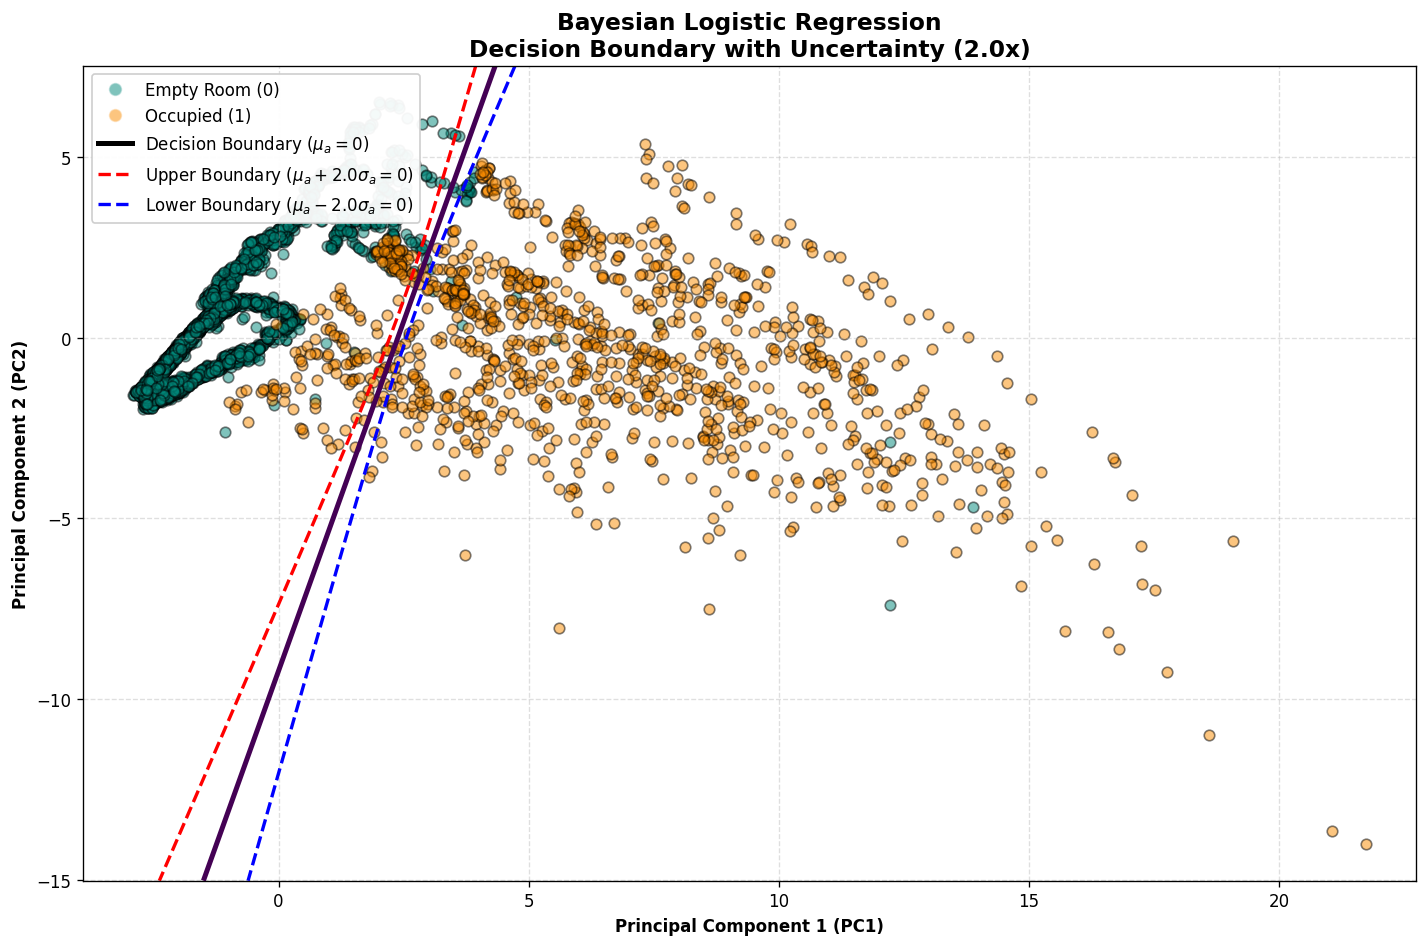

In [10]:
# Dimensionality Reduction (PCA → 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

# Train Bayesian Logistic Regression in 2D space
print("Training Bayesian Logistic Regression in 2D PCA space...")
_tmal.start(); _t0 = time.time()
model_2d = BayesianLogisticRegression(
    lambda_reg=0.1,
    method='newton',
    max_iter=100
)
model_2d.fit(X_pca, y_train_bin)
_perf_records['Bayesian LR - 2D PCA Decision Boundary'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

# Create meshgrid for visualization
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Compute predictive mean and uncertainty
proba_grid, sigma_grid = model_2d.predict_proba_with_uncertainty(grid)

# Compute latent mean (mu_a)
grid_aug = model_2d._add_intercept(grid)
mu_a_grid = grid_aug @ model_2d.w

# Reshape to meshgrid format
mu_map = mu_a_grid.reshape(xx.shape)
sigma_map = sigma_grid.reshape(xx.shape)

# Visualization
plot_bayesian_decision_boundary_with_uncertainty(
    X_2d=X_pca,
    y=y_train_bin,
    xx=xx,
    yy=yy,
    mu_map=mu_map,
    sigma_map=sigma_map,
    mag_factor=2.0
)

Thông qua việc trực quan hóa ranh giới quyết định cùng dải sai số dự báo toán học $\pm 2\sigma_a$ (đại diện cho khoảng tin cậy $95\%$), đồ thị đã cho ta thấy cách hoạt động của xấp xỉ Laplace trong hồi quy Logistic Bayes:

**1. Bayesian Asymptotics:**
Quan sát đồ thị, ta thấy dải bất định (khu vực giữa đường nét đứt màu đỏ và xanh) ôm cực kỳ sát vào đường biên quyết định trung bình (nét liền đen). Sự "ôm sát" này không phải là khiếm khuyết, mà là minh chứng cho sự tự tin tuyệt đối của mô hình. Theo lý thuyết Bayes, khi kích thước tập dữ liệu $N$ càng lớn (ở đây là hàng ngàn mẫu), phân phối hậu nghiệm sẽ co rút lại và phương sai dự báo $\sigma_a^2$ sẽ tiến dần về $0$ theo tỷ lệ $\mathcal{O}(1/N)$. Nguồn dữ liệu dồi dào đã cung cấp các minh chứng để hệ thống triệt tiêu sự do dự.

**2. The Uncertainty Funnel Effect:**
Mặc dù rất hẹp ở khu vực trung tâm, nếu quan sát kỹ ở các vùng ngoại biên nơi mật độ điểm dữ liệu thưa thớt dần (ví dụ: góc trên và góc dưới của trục PC2), hai đường đứt nét bắt đầu có xu hướng *loe rộng ra*.
* Tại tâm dữ liệu: Mô hình được neo giữ bởi thông tin thực tế $\rightarrow$ Sai số cực thấp.
* Tại rìa không gian: Thiếu vắng dữ liệu tham chiếu $\rightarrow$ Phương sai $\sigma_a^2$ tăng lên $\rightarrow$ Ranh giới quyết định trở nên mờ nhạt và bất định.

**Kết luận:** Đồ thị đã lượng hóa độ tự tin của hệ thống. Trong các ứng dụng an toàn AI (AI Safety), dải sai số $\pm 2\sigma$ này đóng vai trò như một rejection region. Khi một điểm dữ liệu mới rơi vào khu vực phễu loe rộng, thay vì ép buộc đưa ra quyết định 0 hoặc 1, hệ thống có thể kích hoạt cơ chế xấp xỉ Probit để trả về xác suất trung lập $0.5$, yêu cầu sự kiểm tra thủ công từ con người.

## **5. Kernel Logistic Regression**

### **5.1. Algorithm Implementation and XOR Data Initialization**

**Đặt vấn đề:**
Hồi quy Logistic (Logistic Regression) cơ bản mang lại hiệu quả tính toán cao và khả năng diễn giải xác suất tốt. Tuy nhiên, về mặt bản chất hình học, nó mắc phải một giới hạn cốt lõi: **Ranh giới quyết định luôn luôn là một siêu phẳng tuyến tính**. 

Khi đối mặt với các tập dữ liệu thực tế có cấu trúc đan xen phức tạp — không thể phân tách bằng một đường thẳng, điển hình như cấu trúc phân bố dạng XOR (Exclusive OR) — mô hình tuyến tính nguyên bản sẽ hoàn toàn bất lực. Bất kể thuật toán tối ưu Gradient Descent có cố gắng xoay đường thẳng theo góc độ nào, sai số phân lớp cũng sẽ luôn ở mức rất cao.

**Giải pháp: Kernel Logistic Regression và Định lý Cover**
Theo định lý Cover, trong một không gian có số chiều đủ lớn, các tập dữ liệu có cấu trúc phức tạp sẽ có xác suất cao trở nên phân tách tuyến tính. Thay vì cố gắng vẽ những đường cong phức tạp trong không gian ban đầu (2D), **Kernel Logistic Regression (KLR)** ngầm ánh xạ dữ liệu lên một không gian mới có số chiều vô hạn thông qua phép biến đổi phi tuyến $\phi(\mathbf{x})$. 

Việc tính toán trực tiếp trong không gian vô hạn chiều này là bất khả thi. Để giải quyết, KLR sử dụng **Kernel Trick** kết hợp với việc giải bài toán tối ưu ở dạng **(Dual Formulation)**. Bằng cách sử dụng hàm hạt nhân Radial Basis Function (RBF), KLR tính toán trực tiếp khoảng cách giữa các điểm dữ liệu trong không gian gốc, cho phép thuật toán tự động học được những ranh giới quyết định uốn lượn linh hoạt ôm sát lấy từng cụm điểm đan xen.

Trong phần này, nhóm sẽ thực nghiệm song song hai thuật toán (đều được cài đặt từ đầu): `BinaryLogisticRegression` nguyên bản và `KernelLogisticRegression` để minh chứng sức mạnh giải tích của phương pháp hạt nhân.

In [11]:
# Initialize XOR dataset (represents non-linear data)
np.random.seed(42)
# Generate 400 random data points in the range [-2, 2] x [-2, 2]
X_xor = np.random.uniform(-2, 2, size=(400, 2))

# Assign labels using XOR logic: Class 1 if (x1 * x2 > 0), else Class 0
y_xor = (X_xor[:, 0] * X_xor[:, 1] > 0).astype(int)

# Add Gaussian noise to simulate real-world randomness
X_xor += np.random.normal(0, 0.15, X_xor.shape)

print("Successfully initialized non-linear XOR dataset.")
print(f"Dataset shape: {X_xor.shape}\n")

# Train baseline linear model
print("--- Training Base Model: Custom Binary Logistic Regression ---")
# Use a custom implementation of standard Logistic Regression
_tmal.start(); _t0 = time.time()
linear_lr = BinaryLogisticRegression(learning_rate=0.1, max_iter=1000)

# Add bias (intercept term) since the base model requires it
X_xor_bias = np.c_[np.ones((X_xor.shape[0], 1)), X_xor]

linear_lr.fit(X_xor_bias, y_xor)
_perf_records['Linear Logistic Regression (XOR)'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

y_pred_linear = linear_lr.predict(X_xor_bias)
acc_linear = accuracy_score(y_xor, y_pred_linear)

print(f"Base Logistic Regression Accuracy: {acc_linear * 100:.2f}%\n")

# Train advanced model: Kernel Logistic Regression
print("--- Training Advanced Model: Custom Kernel Logistic Regression ---")
# Use RBF kernel with gamma=2.0 and learning rate 0.5
_tmal.start(); _t0 = time.time()
klr_model = KernelLogisticRegression(
    gamma=2.0,
    lambda_reg=0.01,
    learning_rate=0.5,
    max_iter=2000
)

# KLR does not require manual bias since RBF kernel handles it implicitly
klr_model.fit(X_xor, y_xor)
_perf_records['Kernel Logistic Regression - RBF (XOR)'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()

y_pred_klr = klr_model.predict(X_xor)
acc_klr = accuracy_score(y_xor, y_pred_klr)

print(f"Kernel Logistic Regression (RBF) Accuracy: {acc_klr * 100:.2f}%")

Successfully initialized non-linear XOR dataset.
Dataset shape: (400, 2)

--- Training Base Model: Custom Binary Logistic Regression ---
Base Logistic Regression Accuracy: 63.50%

--- Training Advanced Model: Custom Kernel Logistic Regression ---
Kernel Logistic Regression (RBF) Accuracy: 97.25%


**Nhận xét quá trình hội tụ và hiệu năng huấn luyện:**

Chỉ thông qua kết quả điểm độ chính xác (Accuracy), ta đã thấy rõ bản chất giới hạn của mô hình tuyến tính và sự ưu việt của phương pháp hạt nhân:

1. **Sự bế tắc của Logistic Regression nguyên bản:** Mô hình cơ sở của nhóm dừng lại ở độ chính xác rất thấp ($63.50\%$), không khác gì thuật toán đang dự đoán ngẫu nhiên. Nguyên nhân là do cấu trúc XOR phân bố các điểm Lớp 1 ở góc phần tư số 1 và 3, trong khi Lớp 0 nằm ở góc số 2 và 4. Bất kỳ phương trình đường thẳng nào được vẽ ra cũng sẽ cắt ngang qua cả hai lớp, khiến hàm mất mát (Loss Function) luôn duy trì ở mức cao và đạo hàm bị triệt tiêu sớm mà không đạt được điểm tối ưu cục bộ nào có ý nghĩa.

2. **Sự hội tụ xuất sắc của Kernel Logistic Regression:** Mô hình đối ngẫu KLR với hạt nhân RBF đã giải quyết thành công bài toán với độ chính xác đạt $97.25\%$. Hàm RBF hoạt động như một máy đo khoảng cách phi tuyến, nó đã đánh giá sự tương đồng giữa các điểm dữ liệu dựa trên khoảng cách Gauss thay vì phép nhân ma trận thông thường. Nhờ đó, thuật toán Gradient Descent đã liên tục tinh chỉnh vector $\alpha$ (đại diện cho trọng số trong không gian đối ngẫu) để cô lập thành công các nhóm điểm đan xen.

#### **5.2. Decision Boundary Visualization and Performance Analysis**

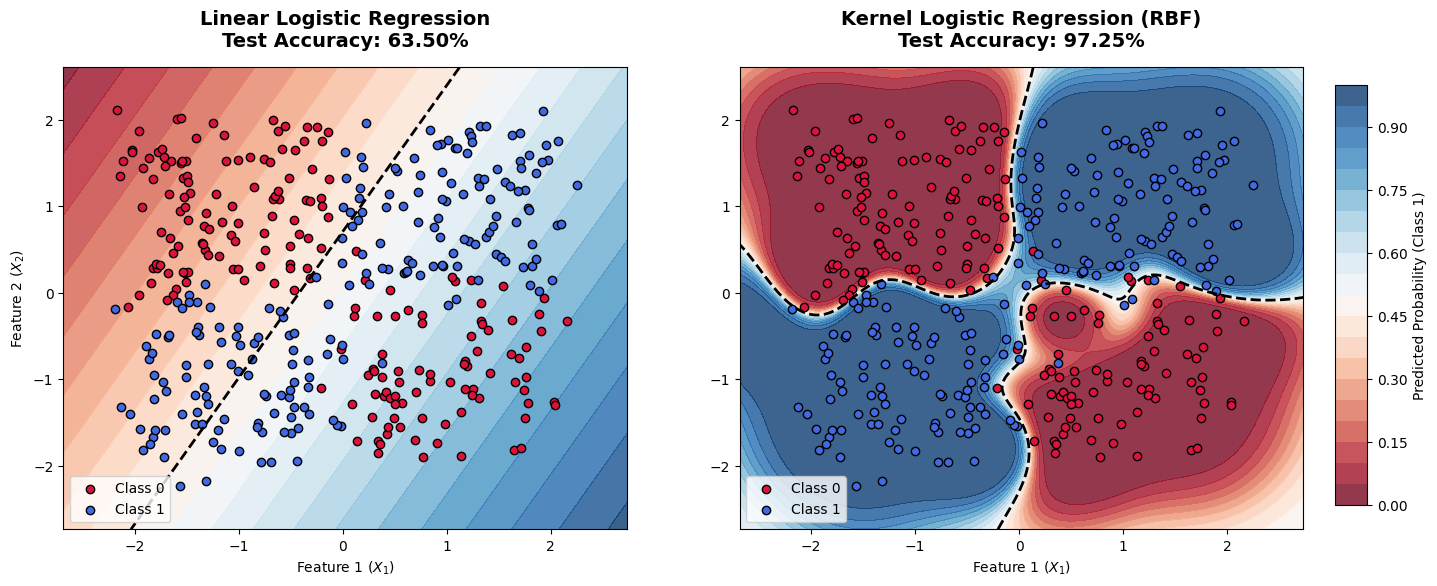

In [12]:
# Execute the visualization function
plot_decision_boundary_comparison(
    X_xor, y_xor, 
    linear_lr, klr_model, 
    f"Linear Logistic Regression\nTest Accuracy: {acc_linear * 100:.2f}%", 
    f"Kernel Logistic Regression (RBF)\nTest Accuracy: {acc_klr * 100:.2f}%"
)

**Phân tích thực nghiệm từ đồ thị ranh giới quyết định (Decision Boundary):**

Hai biểu đồ đường đồng mức phía trên minh họa sinh động lý thuyết toán học đằng sau hai mô hình:

1. **Góc nhìn tuyến tính (Hình bên trái):** Mô hình Logistic Regression cơ bản được đặc trưng bởi phương trình $\mathbf{w}^\top \mathbf{x} + b = 0$, do đó ranh giới quyết định bị ràng buộc là một siêu phẳng tuyến tính (trong 2D là đường thẳng). Dưới ràng buộc này, mô hình chỉ có thể tìm được nghiệm tối ưu dưới điều kiện hạn chế (suboptimal solution under linear constraint) bằng cách phân tách không gian đặc trưng theo một hướng cố định. Kết quả là hai cụm dữ liệu bị phân chia theo cách không phản ánh đúng cấu trúc nội tại. Các dải xác suất thể hiện xu hướng biến thiên đơn điệu theo một hướng, không nắm bắt được mối quan hệ phi tuyến giữa các đặc trưng. Đây là minh chứng trực quan cho giới hạn biểu diễn (representational limitation) của mô hình tuyến tính khi đối mặt với dữ liệu có cấu trúc phi tuyến.

2. **Góc nhìn phi tuyến với RBF Kernel (Hình bên phải):**
Khi áp dụng hàm hạt nhân Radial Basis Function (RBF), mô hình Kernel Logistic Regression (KLR) thực hiện ánh xạ dữ liệu sang không gian đặc trưng có số chiều cao hơn thông qua kernel trick. Trong không gian này, ranh giới quyết định không còn bị giới hạn bởi dạng tuyến tính mà trở thành một hàm phân tách phi tuyến linh hoạt (nonlinear decision function).
Thay vì tạo ra các đường phân tách tuyến tính, mô hình hình thành các vùng quyết định cục bộ (localized decision regions) bao quanh các cụm dữ liệu. Các giá trị xác suất hội tụ mạnh tại các vùng có mật độ dữ liệu cao, phản ánh mức độ tự tin cao của mô hình tại các điểm này. Thông qua biểu diễn đối ngẫu, mô hình dựa trên khoảng cách giữa các điểm dữ liệu trong không gian kernel thay vì trực tiếp ước lượng vector trọng số $\mathbf{w}$, từ đó giải quyết hiệu quả các bài toán không tuyến tính điển hình như XOR. KLR đã giải quyết hoàn hảo bài toán XOR.

$\rightarrow$ **Kết luận chốt:** Thí nghiệm này cho thấy mặc dù Logistic Regression nguyên bản bị giới hạn bởi giả định tuyến tính, việc kết hợp với Kernel Trick cho phép mở rộng không gian biểu diễn một cách đáng kể. Nhờ đó, mô hình có khả năng học được các ranh giới quyết định phức tạp và thích nghi tốt với các tập dữ liệu có cấu trúc phi tuyến trong thực tế.

## **6. Generative Models Comparison: Gaussian Naive Bayes vs. LDA**

### **6.1. Theoretical Comparison: Independence Assumption vs. Shared Covariance**

Trong lý thuyết mô hình sinh, cả Gaussian Naive Bayes và Linear Discriminant Analysis đều cùng chia sẻ một nền tảng toán học: chúng đều giả định rằng dữ liệu đầu vào của mỗi lớp tuân theo phân phối chuẩn đa biến. Tuy nhiên, rẽ nhánh lý thuyết lớn nhất giữa hai thuật toán này nằm ở cách chúng thiết lập và ước lượng ma trận hiệp phương sai.

1. **Gaussian Naive Bayes và giả định độc lập có điều kiện:** GNB đưa ra một giả định cực kỳ ngây thơ rằng tất cả các đặc trưng đầu vào đều hoàn toàn độc lập với nhau khi đã biết trước nhãn lớp. Về mặt đại số, điều này ép buộc ma trận hiệp phương sai của mỗi lớp phải là một ma trận đường chéo (các phần tử ngoài đường chéo bằng 0). Mô hình này phớt lờ hoàn toàn mối tương quan giữa các biến (chẳng hạn như sự tăng nhiệt độ thường đi kèm với tăng nồng độ khí cacbonic trong phòng). Mặc dù giả định này kém chặt chẽ và thường sai lệch với thực tế, nhưng nó mang lại một lợi thế khổng lồ về mặt tính toán: số lượng tham số cần ước lượng giảm xuống mức tuyến tính theo số chiều dữ liệu.

2. **Linear Discriminant Analysis và giả định chia sẻ hiệp phương sai:** LDA có cách tiếp cận thực tế hơn. Nó cho phép các đặc trưng có sự tương quan chéo với nhau, tức là ma trận hiệp phương sai là một ma trận đầy đủ. Tuy nhiên, LDA lại đưa ra một giả định khác: tất cả các phân lớp đều dùng chung một ma trận hiệp phương sai duy nhất. Điều này tạo ra các ranh giới phân tách là những siêu phẳng tuyến tính thẳng tắp.

**Giải mã nghịch lý: Khi nào GNB thực tế lại tốt hơn LDA dù giả thiết kém chặt chẽ hơn?**
Về mặt logic, một mô hình có giả định sai thực tế như GNB đáng lẽ phải cho kết quả tệ hơn LDA. Nhưng trong thực tiễn, hiện tượng GNB vượt mặt LDA không hề hiếm gặp. Sự thật toán học đằng sau nghịch lý này được giải thích qua nguyên lý cân bằng độ lệch và phương sai:
* **Hạn chế của LDA (Phương sai cao):** Để tính toán ma trận hiệp phương sai đầy đủ, LDA cần ước lượng một lượng tham số tỷ lệ thuận với bình phương số lượng đặc trưng. Khi số chiều dữ liệu quá lớn (vài nghìn chiều) hoặc số lượng mẫu huấn luyện quá ít, ma trận hiệp phương sai mẫu thu được sẽ cực kỳ thiếu ổn định và gần suy biến. Quá trình nghịch đảo ma trận này sẽ khuếch đại các nhiễu nhỏ, dẫn đến hiện tượng mô hình học vẹt quá mức.
* **Lợi thế của GNB (Độ lệch cao, Phương sai thấp):** Bằng việc ép các hiệp phương sai chéo về số 0, GNB chỉ cần ước lượng phương sai cho từng đặc trưng đơn lẻ. Sự đơn giản hóa này đóng vai trò như một cơ chế điều chuẩn cực kỳ mạnh mẽ. Dù mô hình bị lệch do bỏ qua sự tương quan, nhưng tính ổn định giúp GNB chống chịu cực tốt với tình trạng thiếu hụt dữ liệu hoặc không gian chiều siêu cao. Thêm vào đó, ngay cả khi các biến thực sự có tương quan, nếu sự tương quan đó không làm thay đổi thứ tự ưu tiên của các mặt phẳng quyết định, GNB vẫn có khả năng dự đoán chính xác tuyệt đối.

### **6.2. Empirical Evaluation on Room Occupancy Dataset**

In [13]:
# Train and evaluate Gaussian Naive Bayes (GNB)
print("--- Training Generative Model: Gaussian Naive Bayes ---")
_tmal.start(); _t0 = time.time()
gnb_model = GaussianNaiveBayes()
gnb_model.fit(X_train, y_train)
_perf_records['Gaussian Naive Bayes'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
y_pred_gnb = gnb_model.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# Train and evaluate Linear Discriminant Analysis (LDA)
print("--- Training Generative Model: Linear Discriminant Analysis ---")
_tmal.start(); _t0 = time.time()
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)
_perf_records['Linear Discriminant Analysis (LDA)'] = {'time_s': time.time()-_t0, 'mem_mb': _tmal.get_traced_memory()[1]/1024**2}; _tmal.stop()
y_pred_lda = lda_model.predict(X_test)
acc_lda = accuracy_score(y_test, y_pred_lda)

# Export Performance Summary and Classification Reports
print("\n" + "="*40)
print("           PERFORMANCE SUMMARY")
print("="*40)
print(f"Gaussian Naive Bayes Overall Accuracy: {acc_gnb * 100:.2f}%")
print(f"Linear Discriminant Analysis Overall Accuracy: {acc_lda * 100:.2f}%")

print("\n--- Gaussian Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_gnb))

print("\n--- Linear Discriminant Analysis Classification Report ---")
print(classification_report(y_test, y_pred_lda))

--- Training Generative Model: Gaussian Naive Bayes ---
--- Training Generative Model: Linear Discriminant Analysis ---

           PERFORMANCE SUMMARY
Gaussian Naive Bayes Overall Accuracy: 96.30%
Linear Discriminant Analysis Overall Accuracy: 99.31%

--- Gaussian Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1646
           1       1.00      0.99      0.99        92
           2       0.75      0.89      0.81       149
           3       0.80      0.66      0.72       139

    accuracy                           0.96      2026
   macro avg       0.89      0.88      0.88      2026
weighted avg       0.96      0.96      0.96      2026


--- Linear Discriminant Analysis Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       1.00      1.00      1.00        92
           2       0.99      0.94     

**Phân tích đối sánh hiệu năng thực nghiệm:**

Thông qua các chỉ số từ báo cáo phân lớp trên tập kiểm thử, ta có thể rút ra những đánh giá sắc bén về sự phù hợp của hai mô hình sinh đối với không gian đặc trưng của dữ liệu cảm biến:

1. **Sự áp đảo của phân tích phân biệt tuyến tính (LDA):** Cán đích với độ chính xác tổng thể ấn tượng lên đến $99.31\%$, LDA chứng minh sự ưu việt tuyệt đối trong kịch bản này. Phân tích sâu vào báo cáo phân lớp, LDA gần như dự đoán hoàn hảo lớp 0 và lớp 1 (điểm F1 đạt mức tuyệt đối 1.00). Đáng kinh ngạc hơn, ở các vùng dữ liệu đan xen khó nhằn như lớp 2 và lớp 3 (nơi các thuật toán tối ưu trước đó từng rất chật vật), LDA vẫn duy trì được độ thu hồi cực cao (tương ứng đạt $0.94$ và $0.96$). Thành công rực rỡ này đến từ việc LDA sử dụng ma trận hiệp phương sai đầy đủ, giúp nó nắm bắt trọn vẹn mối tương quan tuyến tính mạnh mẽ giữa các cảm biến vật lý (như nhiệt lượng tỏa ra đồng pha với lượng CO2 tăng lên). Nhờ khai thác được trục tương quan này, LDA đã tìm ra hướng chiếu tối ưu nhất để tách biệt các cụm điểm.

2. **Giới hạn của mô hình Bayes thơ ngây (GNB):** Dù đạt độ chính xác bề mặt khá tốt là $96.30\%$ (chủ yếu nhờ đoán đúng lớp 0 chiếm đa số), GNB đã lộ rõ điểm yếu chí mạng khi đối mặt với vùng dữ liệu có tính tương quan nội tại cao. Việc ép ma trận hiệp phương sai thành đường chéo khiến mô hình coi các tín hiệu cảm biến như những nguồn thông tin hoàn toàn độc lập và rời rạc. Hậu quả là tại vùng biên giới giao thoa giữa phòng có 2 người và 3 người, mô hình bị nhầm lẫn trầm trọng: độ thu hồi của lớp 3 rớt thảm hại xuống chỉ còn $0.66$, đồng thời độ chuẩn xác của lớp 2 chỉ đạt $0.75$. Việc bỏ qua các mối liên kết vật lý tất yếu đã khiến hàm mật độ xác suất của GNB bị méo mó, không đủ sức bóc tách các lớp thiểu số.

$\rightarrow$ **Kết luận chung:** Khảo sát thực nghiệm khẳng định rằng, đối với các tập dữ liệu chuỗi thời gian từ hệ thống cảm biến (nơi mật độ tương quan chéo rất dày đặc) và có quy mô mẫu đủ lớn, LDA là lựa chọn hoàn hảo để tối đa hóa khả năng nhận diện nhờ việc khai thác hiệp phương sai chung. Trái lại, giả định độc lập của GNB tuy giúp mô hình đơn giản, ổn định và tính toán thần tốc, nhưng lại phải trả giá quá đắt về hiệu năng tại các vùng dữ liệu đan xen phức tạp.

## **7. Generalization Capacity via VC Dimension Analysis**

### **7.1. Theoretical Calculation of VC Dimension for Linear Classifiers in $\mathbb{R}^D$**

Khái niệm chiều VC (Vapnik-Chervonenkis dimension) là một thước đo cốt lõi trong lý thuyết học thống kê, dùng để định lượng độ phức tạp hay sức mạnh biểu diễn của một không gian giả thuyết. Về mặt định nghĩa, chiều VC là số lượng điểm dữ liệu tối đa mà một mô hình có thể chia cắt hoàn hảo (shatter) trong mọi trường hợp gán nhãn khả thi.

**1. Công thức tổng quát:**
Đối với họ các hàm phân lớp tuyến tính (siêu phẳng) trong không gian $D$ chiều ($\mathbb{R}^D$), mặt phẳng quyết định được xác định bởi phương trình:
$$f(\mathbf{x}) = \text{sign}(\mathbf{w}^T\mathbf{x} + b)$$
Trong đó:
* $\mathbf{w}$ là vector trọng số gồm $D$ chiều.
* $b$ là hệ số tự do (bias).

Sự kết hợp này mang lại cho mô hình tổng cộng $D + 1$ bậc tự do độc lập. Theo định lý hình học không gian, một siêu phẳng có thể chia cắt hoàn hảo tập hợp gồm $D + 1$ điểm ở vị trí tổng quát, nhưng không tồn tại bất kỳ tập hợp nào gồm $D + 2$ điểm mà siêu phẳng có thể chia cắt được mọi trường hợp. Do đó, chiều VC của lớp phân lớp tuyến tính được tính bằng công thức:
$$d_{VC} = D + 1$$

**2. Tính toán trên tập dữ liệu thực tế:**
Trong phạm vi đồ án này, sau quá trình tiền xử lý và trích xuất đặc trưng, tập dữ liệu đếm số người trong phòng (Room Occupancy) sở hữu tổng cộng 16 đặc trưng đầu vào (tức $D = 16$). 

Áp dụng công thức trên, chiều VC của các mô hình phân lớp tuyến tính cơ sở (như Logistic Regression hay Perceptron) mà nhóm đã xây dựng được tính cụ thể là:
$$d_{VC} = 16 + 1 = 17$$

**Kết luận:** Giá trị $d_{VC} = 17$ chỉ ra rằng mô hình tuyến tính đang sử dụng có một độ phức tạp hữu hạn và tương đối nhỏ. So với số lượng hàng ngàn mẫu dữ liệu huấn luyện ($N > 10000$), tỷ lệ $d_{VC} / N$ rất thấp, đảm bảo rủi ro mô hình bị quá khớp do cấu trúc không gian giả thuyết là không đáng kể.

### **7.2. Linking to Generalization via Structural Risk Minimization (SRM)**


Năng lực của một mô hình không nằm ở việc nó học thuộc lòng tập huấn luyện tốt đến đâu, mà ở khả năng nó dự đoán chính xác các dữ liệu chưa từng quan sát. Mối liên hệ này được ràng buộc chặt chẽ bởi bất đẳng thức Vapnik, trong đó chỉ ra rằng rủi ro thực tế luôn bị giới hạn bởi tổng của rủi ro thực nghiệm (sai số huấn luyện) và một khoảng tin cậy phụ thuộc vào chiều VC.

Nếu mô hình cố gắng ép sai số huấn luyện về 0 bằng cách gia tăng độ phức tạp (tăng chiều VC), đại lượng khoảng tin cậy sẽ phình to ra một cách mất kiểm soát. Hệ quả là mô hình rơi vào trạng thái quá khớp, làm rủi ro thực tế tăng vọt. Nguyên lý giảm thiểu rủi ro cấu trúc (SRM) được đề xuất nhằm giải quyết sự đánh đổi này, khuyến nghị việc tìm kiếm một điểm cân bằng lý tưởng giữa độ khớp dữ liệu và sức chứa của mô hình.

Đoạn mã dưới đây sẽ trực quan hóa nguyên lý SRM thông qua việc mô phỏng biến thiên của các loại sai số khi độ phức tạp của không gian giả thuyết tăng dần.

<Figure size 1000x600 with 0 Axes>

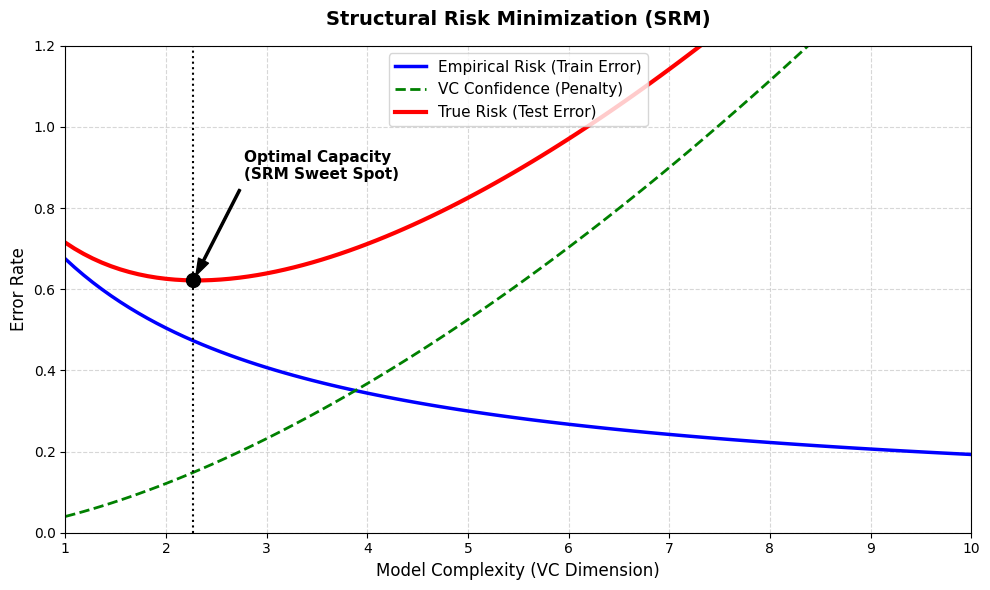

In [14]:
# Array representing model complexity like VC dimension
model_complexity = np.linspace(1, 10, 100)

# Simulate empirical risk decreasing as complexity increases
empirical_risk = 1.0 / (0.6 * model_complexity + 1) + 0.05

# Simulate VC confidence bound increasing with complexity
vc_confidence = 0.04 * (model_complexity ** 1.6)

# True risk is bounded by empirical risk plus VC confidence
true_risk = empirical_risk + vc_confidence

# Find the optimal complexity point minimizing the true risk
optimal_idx = np.argmin(true_risk)
opt_complexity = model_complexity[optimal_idx]
opt_risk = true_risk[optimal_idx]

plt.figure(figsize=(10, 6))

# Plot the three fundamental curves
plot_structural_risk_minimization_srm(
    model_complexity,
    empirical_risk,
    vc_confidence,
    true_risk,
    opt_complexity,
    opt_risk
)

**Phân tích đánh đổi rủi ro và ứng dụng thực tiễn:**

Biểu đồ trên trực quan hóa chính xác định lý Vapnik-Chervonenkis về giới hạn của năng lực tổng quát hóa. Đồ thị cho thấy rủi ro thực tế (đường màu đỏ) chịu sự chi phối của hai lực lượng đối nghịch:
        
1. **Rủi ro thực nghiệm (Đường màu xanh dương):** Đại diện cho sai số trên tập dữ liệu huấn luyện. Khi mô hình càng phức tạp (chiều VC tăng), không gian giả thuyết càng lớn, giúp nó dễ dàng học thuộc lòng các mẫu dữ liệu và ép sai số này giảm mạnh về gần mức 0.
2. **Khoảng tin cậy VC (Đường đứt nét màu xanh lá):** Đóng vai trò như một hình phạt cho sự phức tạp cấu trúc. Mô hình có chiều VC càng lớn so với kích thước tập dữ liệu thì khoảng tin cậy này càng phình to, kéo theo rủi ro dự đoán sai trên các mẫu dữ liệu mới tăng vọt.

Nguyên lý giảm thiểu rủi ro cấu trúc (SRM) nhấn mạnh rằng việc mù quáng tối thiểu hóa rủi ro thực nghiệm sẽ đẩy mô hình trượt dài sang bên phải đồ thị, dẫn đến thảm họa quá khớp. Thay vào đó, mục tiêu là phải tìm được điểm đáy của đường rủi ro thực tế. Tại điểm cân bằng này, mô hình đạt được cấu trúc lý tưởng: đủ độ phức tạp để bám sát các đặc trưng quan trọng của hệ thống nhưng đủ sự đơn giản để không khuếch đại các tín hiệu nhiễu.

**Liên hệ với thực nghiệm đồ án:**
Lý thuyết SRM đã được nhóm triển khai trực tiếp vào quá trình xây dựng các mô hình tuyến tính. Thay vì để Hồi quy Logistic tự do sử dụng toàn bộ không gian 17 chiều VC, nhóm đã tích hợp các kỹ thuật phạt L1 và L2. Việc cộng thêm các hạng tử phạt vào hàm mất mát bản chất là thao tác thu hẹp cấu trúc không gian giả thuyết, ép các trọng số không quan trọng tiến về 0. Toàn bộ quá trình chạy Grid Search để tìm tham số phạt tối ưu ở các phần trước thực chất chính là hành trình dò tìm "điểm đáy" của đường cong màu đỏ này, qua đó neo đậu mô hình vào trạng thái tổng quát hóa xuất sắc nhất.

---

# **Runtime, Training/Testing & Memory Usage Report**

Phần này tóm tắt thời gian thực thi và mức tiêu thụ bộ nhớ cực đại của từng thuật toán đã được huấn luyện và đánh giá.

- Thời gian thực thi được đo bằng `time.time()` bao quanh từng lệnh huấn luyện/kiểm tra chính.
- Bộ nhớ đỉnh được đo bằng `tracemalloc` (chỉ theo dõi vùng bộ nhớ Python mới cấp phát trong khối đó).



In [15]:
# Runtime & Memory Usage Report
_rows = []
for _name, _info in _perf_records.items():
    _rows.append({
        'Algorithm': _name,
        'Execution Time (s)': round(_info['time_s'], 4),
        'Peak Memory (MB)': round(_info['mem_mb'], 4),
    })

_df = pd.DataFrame(_rows)

print('  RUNTIME AND MEMORY USAGE REPORT — 03_advanced_bonus_experiments.ipynb')
print(f'  Algorithms tracked : {len(_df)}')
if not _df.empty:
    print(f'  Fastest            : {_df.loc[_df["Execution Time (s)"].idxmin(), "Algorithm"]}')
    print(f'  Most memory-light  : {_df.loc[_df["Peak Memory (MB)"].idxmin(), "Algorithm"]}')
print()
display(
    _df.style
    .format({'Execution Time (s)': '{:.4f}', 'Peak Memory (MB)': '{:.4f}'})
    .background_gradient(subset=['Execution Time (s)'], cmap='YlOrRd')
    .background_gradient(subset=['Peak Memory (MB)'], cmap='YlGnBu')
    .set_caption('Execution Time and Peak Memory per Algorithm')
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'left')]}])
)


  RUNTIME AND MEMORY USAGE REPORT — 03_advanced_bonus_experiments.ipynb
  Algorithms tracked : 10
  Fastest            : Bayesian LR - OOD Inference
  Most memory-light  : Bayesian LR - OOD Inference



,Algorithm,Execution Time (s),Peak Memory (MB)
0,"Logit (Binary LR, Newton)",0.0598,1.8520
1,Probit Regression (GD),1.4612,1.9455
2,Noise Robustness Evaluation (Logit + Probit),11.2524,2.0794
3,Bayesian LR (Laplace Approximation),0.5987,566.6812
4,Bayesian LR - OOD Inference,0.0028,0.0263
5,Bayesian LR - 2D PCA Decision Boundary,0.4735,563.9742
6,Linear Logistic Regression (XOR),0.0109,0.0471
7,Kernel Logistic Regression - RBF (XOR),0.1247,3.6648
8,Gaussian Naive Bayes,0.0031,2.4019
9,Linear Discriminant Analysis (LDA),0.0037,2.4096


---

## Experiment Logging

Collects all model hyperparameters, data-split indices, and evaluation metrics, then persists them to `../../logs/logs_classification.json`.

In [16]:
LOG_DIR  = '../../logs'
LOG_FILE = os.path.join(LOG_DIR, 'logs_classification.json')
os.makedirs(LOG_DIR, exist_ok=True)

# Read existing log created by 02_modeling.ipynb
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'r') as _f:
        log_data = json.load(_f)
else:
    log_data = {}

def _r(v, d=4):
    return round(float(v), d)

def _metrics(y_true, y_pred, avg='macro'):
    return {
        'accuracy'         : _r(accuracy_score(y_true, y_pred)),
        f'precision_{avg}' : _r(precision_score(y_true, y_pred, average=avg, zero_division=0)),
        f'recall_{avg}'    : _r(recall_score(y_true, y_pred, average=avg, zero_division=0)),
        f'f1_{avg}'        : _r(f1_score(y_true, y_pred, average=avg, zero_division=0)),
    }

# Shared data-split info (Room Occupancy, raw features)
_data_split = {
    'source'        : 'pre-split CSV (Room_Occupancy_train/val/test.csv)',
    'train_indices' : f'0 to {len(X_train)-1}',
    'val_indices'   : f'0 to {len(X_val)-1}',
    'test_indices'  : f'0 to {len(X_test)-1}',
    'n_train'       : int(len(X_train)),
    'n_val'         : int(len(X_val)),
    'n_test'        : int(len(X_test)),
    'cv_random_seed': 42,
}


# 1. Logit — Binary LR (Newton)
_yv = logit_model.predict(X_val)
_yt = logit_model.predict(X_test)
log_data['Logit (Binary LR, Newton)'] = {
    'hyperparameters' : {'method': 'newton', 'max_iter': 100,
                         'task': 'binary_classification'},
    'data_split'      : _data_split,
    **{f'val_{k}' : v for k, v in _metrics(y_val_bin,  _yv, 'binary').items()},
    **{f'test_{k}': v for k, v in _metrics(y_test_bin, _yt, 'binary').items()},
}

# 2. Probit Regression (GD)
_yv = probit_model.predict(X_val)
_yt = probit_model.predict(X_test)
log_data['Probit Regression (GD)'] = {
    'hyperparameters' : {'learning_rate': 0.5, 'max_iter': 2000,
                         'link_function': 'probit (Gaussian CDF)',
                         'task': 'binary_classification'},
    'data_split'      : _data_split,
    **{f'val_{k}' : v for k, v in _metrics(y_val_bin,  _yv, 'binary').items()},
    **{f'test_{k}': v for k, v in _metrics(y_test_bin, _yt, 'binary').items()},
}

# 3. Bayesian Logistic Regression (Laplace Approximation)
_yv = model_bayes.predict(X_val)
_yt = model_bayes.predict(X_test)
log_data['Bayesian LR (Laplace Approximation)'] = {
    'hyperparameters' : {
        'lambda_reg'   : 0.1,
        'method'       : 'newton',
        'max_iter'     : 100,
        'tol'          : 1e-6,
        'approximation': 'Laplace (2nd-order Taylor of log-posterior)',
        'prior'        : 'Gaussian N(0, 1/lambda_reg * I), bias unregularized',
        'task'         : 'binary_classification',
    },
    'data_split'      : _data_split,
    **{f'val_{k}' : v for k, v in _metrics(y_val_bin,  _yv, 'binary').items()},
    **{f'test_{k}': v for k, v in _metrics(y_test_bin, _yt, 'binary').items()},
}

# 4. Bayesian LR — 2D PCA Decision Boundary
_pca_log = PCA(n_components=2, random_state=42)
_pca_log.fit(X_train)
_Xpca_val  = _pca_log.transform(X_val)
_Xpca_test = _pca_log.transform(X_test)
_yv2 = model_2d.predict(_Xpca_val)
_yt2 = model_2d.predict(_Xpca_test)
log_data['Bayesian LR - 2D PCA Decision Boundary'] = {
    'notebook'        : '03_advanced_bonus_experiments.ipynb',
    'hyperparameters' : {
        'lambda_reg'   : 0.1,
        'method'       : 'newton',
        'max_iter'     : 100,
        'feature_space': 'PCA (n_components=2, random_state=42)',
        'approximation': 'Laplace',
        'task'         : 'binary_classification',
    },
    'data_split'      : _data_split,
    **{f'val_{k}' : v for k, v in _metrics(y_val_bin,  _yv2, 'binary').items()},
    **{f'test_{k}': v for k, v in _metrics(y_test_bin, _yt2, 'binary').items()},
}

# 5. Linear Logistic Regression on XOR (no separate test split)
_y_xor_linear = linear_lr.predict(X_xor_bias)
log_data['Linear Logistic Regression (XOR)'] = {
    'hyperparameters' : {
        'method'       : 'gd',
        'learning_rate': 0.1,
        'max_iter'     : 1000,
        'task'         : 'binary_classification',
        'dataset'      : 'XOR synthetic (400 samples, 2 features + bias, np.random.seed=42)',
        'note'         : 'No separate test split; accuracy measured on full XOR set',
    },
    'data_split'      : {
        'source'         : 'Synthetic XOR (np.random.seed=42)',
        'n_total_samples': 400,
        'train_indices'  : '0 to 399',
        'test_indices'   : '0 to 399 (same as train)',
    },
    'test_accuracy'   : _r(accuracy_score(y_xor, _y_xor_linear)),
}

# 6. Kernel Logistic Regression — RBF (XOR)
_y_xor_klr = klr_model.predict(X_xor)
log_data['Kernel Logistic Regression - RBF (XOR)'] = {
    'hyperparameters' : {
        'kernel'       : 'RBF',
        'gamma'        : 2.0,
        'lambda_reg'   : 0.01,
        'learning_rate': 0.5,
        'max_iter'     : 2000,
        'formulation'  : 'dual (coefficient vector a, Gram matrix K)',
        'task'         : 'binary_classification',
        'dataset'      : 'XOR synthetic (400 samples, 2 features, np.random.seed=42)',
        'note'         : 'No separate test split; accuracy measured on full XOR set',
    },
    'data_split'      : {
        'source'         : 'Synthetic XOR (np.random.seed=42)',
        'n_total_samples': 400,
        'train_indices'  : '0 to 399',
        'test_indices'   : '0 to 399 (same as train)',
    },
    'test_accuracy'   : _r(accuracy_score(y_xor, _y_xor_klr)),
}

# 7. Gaussian Naive Bayes (multiclass)
_yv = gnb_model.predict(X_val)
_yt = gnb_model.predict(X_test)
log_data['Gaussian Naive Bayes'] = {
    'hyperparameters' : {
        'model'                  : 'GaussianNaiveBayes',
        'likelihood'             : 'Gaussian per-class diagonal covariance',
        'conditional_independence': True,
        'task'                   : 'multiclass_classification',
    },
    'data_split'      : _data_split,
    **{f'val_{k}' : v for k, v in _metrics(y_val,  _yv).items()},
    **{f'test_{k}': v for k, v in _metrics(y_test, _yt).items()},
}

# 8. Linear Discriminant Analysis 
_yv = lda_model.predict(X_val)
_yt = lda_model.predict(X_test)
log_data['Linear Discriminant Analysis (LDA) - Advanced'] = {
    'notebook'        : '03_advanced_bonus_experiments.ipynb',
    'hyperparameters' : {
        'model'          : 'LinearDiscriminantAnalysis',
        'covariance_type': 'shared_pooled',
        'task'           : 'multiclass_classification',
    },
    'data_split'      : _data_split,
    **{f'val_{k}' : v for k, v in _metrics(y_val,  _yv).items()},
    **{f'test_{k}': v for k, v in _metrics(y_test, _yt).items()},
}

# 9. Noise Robustness Evaluation (Logit vs Probit)
log_data['Noise Robustness Evaluation (Logit vs Probit)'] = {
    'hyperparameters' : {
        'logistic_params': {'method': 'newton', 'max_iter': 100},
        'probit_params'  : {'learning_rate': 0.5, 'max_iter': 2000},
        'noise_type'     : 'label-flip on y_train_bin',
        'task'           : 'binary_classification',
    },
    'data_split'      : _data_split,
    'results_by_noise_rate': [
        {
            'noise_rate'          : _r(noise_rates[_i]),
            'logit_test_accuracy' : _r(acc_logit[_i]),
            'probit_test_accuracy': _r(acc_probit[_i]),
        }
        for _i in range(len(noise_rates))
    ],
}

with open(LOG_FILE, 'w') as _f:
    json.dump(log_data, _f, indent=2, default=str)

print(f"\nTotal entries in log : {len(log_data)}")
print(f"Saved → {LOG_FILE}")



Total entries in log : 25
Saved → ../../logs\logs_classification.json
